In [1]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [3]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [4]:
summary, outlier_rows = detect_outliers_iqr(df, city="New York");
print(summary.sort_values(by="Outliers_Count", ascending=False));

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
10        Wind_speed              18         1.11        18.59
4                 CO              17        60.53       556.23
0              PM2.5              10        -3.43        34.91
5                SO2              10        -1.27        13.12
1               PM10               9        -4.99        50.91
2                 O3               5       -18.08       111.30
3                NO2               3        -3.03        70.17
11          Pressure               3       995.23      1036.83
7   Temperature_mean               1        -8.34        39.86
6        Green_Space               0       124.00       124.00
9           Humidity               0        17.79       107.43
8    Temperature_max               0       -11.50        48.50


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11704\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11704\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_11704\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

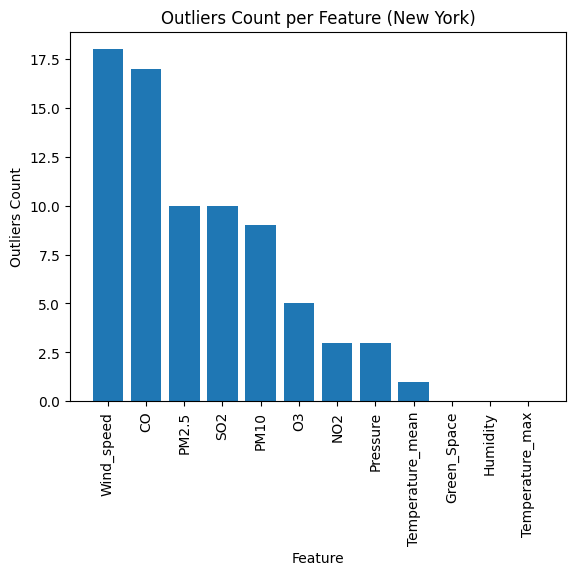

In [5]:
summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)
plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (New York)")
plt.show()

In New York, the highest number of outliers was observed in Wind Speed and CO, suggesting that abnormal environmental conditions were mainly associated with wind fluctuations and air pollution indicators.

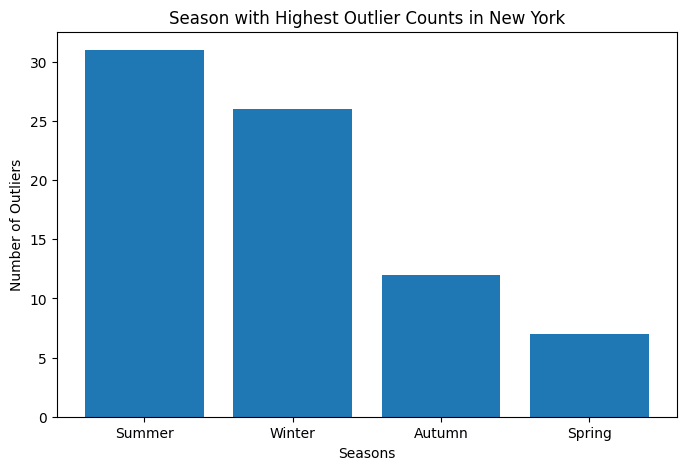

In [6]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in New York")

plt.show()

Summer recorded the highest number of outliers in New York, followed by Winter, indicating greater variability in environmental and pollution-related conditions during these seasons. In contrast, Spring showed the fewest outliers, suggesting more stable environmental conditions.

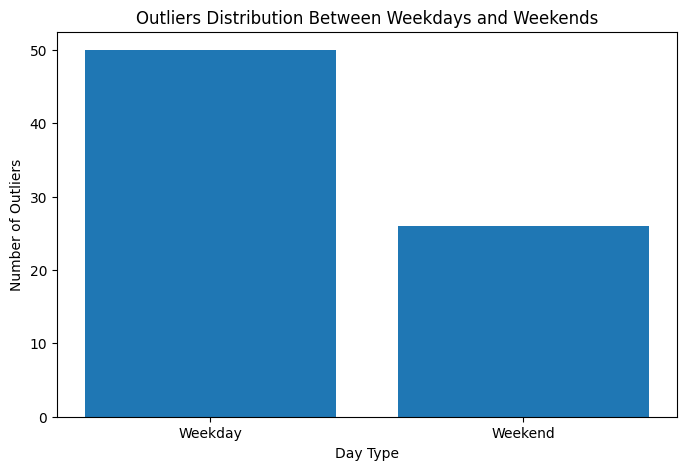

In [7]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in New York appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [8]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,2.833931e+01,2.034546e+01
PM10,4.115033e+01,3.711227e+01
O3,5.029989e+01,5.466602e+01
NO2,4.542253e+01,3.304917e+01
CO,4.715614e+02,3.369445e+02
SO2,9.229770e+00,1.459830e+01
Green_Space,1.240000e+02,1.047314e+02
Temperature_mean,1.484255e+01,1.914092e+01
Temperature_max,1.843421e+01,2.338573e+01
Humidity,6.590961e+01,6.454194e+01


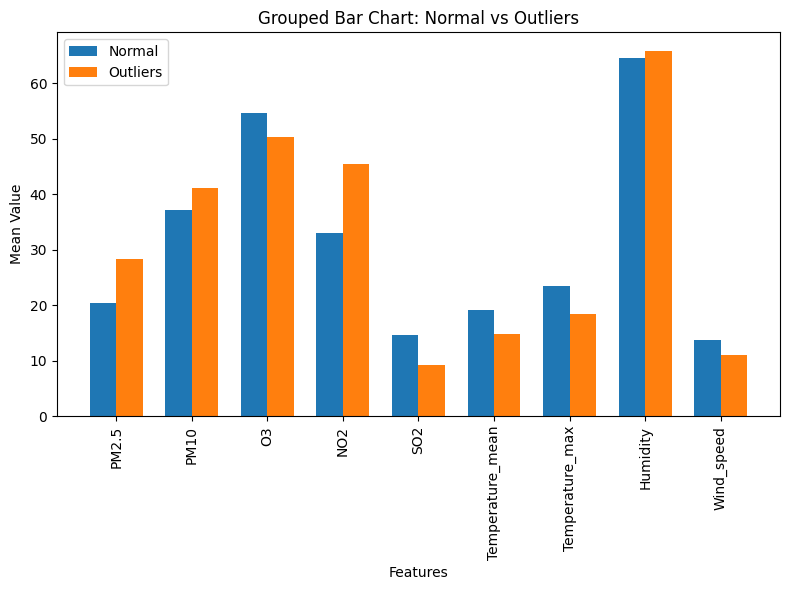

In [9]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier observations in New York were associated with increased PM2.5, PM10, and NO2 levels, while most weather-related variables showed lower values compared to normal conditions.

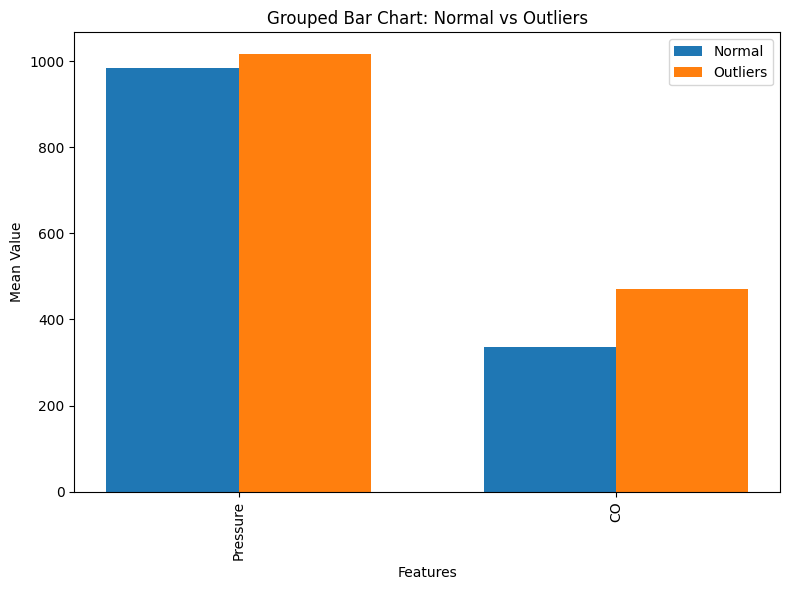

In [10]:
others= comparison.loc[["Pressure","CO"],:]
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

Outlier observations in New York showed significantly higher CO levels, while Pressure values remained relatively close to normal conditions.